## Step 1: Import libraries

In [3]:
import os

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
os.getcwd()

'C:\\Users\\User\\OneDrive - Universiti Kebangsaan Malaysia\\sem 2\\MACHINE LEARNING\\ML\\ASSIGNMENT1'

## Step 2: Import dataset

In [6]:
ed=pd.read_csv('energydata_complete.csv')
print(ed)

                      date  Appliances  lights         T1       RH_1  \
0      2016-01-11 17:00:00          60      30  19.890000  47.596667   
1      2016-01-11 17:10:00          60      30  19.890000  46.693333   
2      2016-01-11 17:20:00          50      30  19.890000  46.300000   
3      2016-01-11 17:30:00          50      40  19.890000  46.066667   
4      2016-01-11 17:40:00          60      40  19.890000  46.333333   
...                    ...         ...     ...        ...        ...   
19730  2016-05-27 17:20:00         100       0  25.566667  46.560000   
19731  2016-05-27 17:30:00          90       0  25.500000  46.500000   
19732  2016-05-27 17:40:00         270      10  25.500000  46.596667   
19733  2016-05-27 17:50:00         420      10  25.500000  46.990000   
19734  2016-05-27 18:00:00         430      10  25.500000  46.600000   

              T2       RH_2         T3       RH_3         T4  ...         T9  \
0      19.200000  44.790000  19.790000  44.730000  19.0

In [7]:
ed.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## Step 3: Data cleaning & preprocessing

In [9]:
#Check for missing values
summary_missing=ed.isna().sum()
print(summary_missing)

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64


In [10]:
#Check for duplicated rows
dupli=ed.duplicated().sum()
print(dupli)

0


In [11]:
#Check data types 
ed.dtypes

date            object
Appliances       int64
lights           int64
T1             float64
RH_1           float64
T2             float64
RH_2           float64
T3             float64
RH_3           float64
T4             float64
RH_4           float64
T5             float64
RH_5           float64
T6             float64
RH_6           float64
T7             float64
RH_7           float64
T8             float64
RH_8           float64
T9             float64
RH_9           float64
T_out          float64
Press_mm_hg    float64
RH_out         float64
Windspeed      float64
Visibility     float64
Tdewpoint      float64
rv1            float64
rv2            float64
dtype: object

In [12]:
#Display all columns name
print(ed.columns.tolist())

['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']


In [13]:
#Drop date column
ed=ed.drop(columns=['date'])

In [14]:
#Check correlation of predictor with response variable (Appliances)
ed.corr()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
Appliances,1.000000,0.197278,0.055447,0.086031,0.120073,-0.060465,0.085060,0.036292,0.040281,0.016965,...,0.010010,-0.051462,0.099155,-0.034885,-0.152282,0.087122,0.000230,0.015353,-0.011145,-0.011145
lights,0.197278,1.000000,-0.023528,0.106968,-0.005622,0.050985,-0.097393,0.131161,-0.008859,0.114936,...,-0.157592,-0.008766,-0.074424,-0.010576,0.068543,0.060281,0.020038,-0.036322,0.000521,0.000521
T1,0.055447,-0.023528,1.000000,0.164006,0.836834,-0.002509,0.892402,-0.028550,0.877001,0.097861,...,0.844777,0.071756,0.682846,-0.150574,-0.345481,-0.087654,-0.076210,0.571309,-0.006203,-0.006203
RH_1,0.086031,0.106968,0.164006,1.000000,0.269839,0.797535,0.253230,0.844677,0.106180,0.880359,...,0.115263,0.764001,0.340767,-0.293957,0.274126,0.204932,-0.021057,0.639106,-0.000699,-0.000699
T2,0.120073,-0.005622,0.836834,0.269839,1.000000,-0.165610,0.735245,0.121497,0.762066,0.231563,...,0.675535,0.157346,0.792255,-0.133028,-0.505291,0.052495,-0.069721,0.582602,-0.011087,-0.011087
RH_2,-0.060465,0.050985,-0.002509,0.797535,-0.165610,1.000000,0.137319,0.678326,-0.047304,0.721435,...,0.054544,0.676467,0.033674,-0.255646,0.584911,0.069190,-0.005368,0.499152,0.006275,0.006275
T3,0.085060,-0.097393,0.892402,0.253230,0.735245,0.137319,1.000000,-0.011234,0.852778,0.122737,...,0.901324,0.134602,0.699417,-0.189974,-0.281718,-0.100776,-0.102310,0.645886,-0.005194,-0.005194
RH_3,0.036292,0.131161,-0.028550,0.844677,0.121497,0.678326,-0.011234,1.000000,-0.140457,0.898978,...,-0.195270,0.833538,0.118207,-0.233274,0.356192,0.263188,0.017041,0.414387,-0.000477,-0.000477
T4,0.040281,-0.008859,0.877001,0.106180,0.762066,-0.047304,0.852778,-0.140457,1.000000,-0.048650,...,0.889439,-0.025549,0.663478,-0.075292,-0.388602,-0.185747,-0.104768,0.519471,-0.001815,-0.001815
RH_4,0.016965,0.114936,0.097861,0.880359,0.231563,0.721435,0.122737,0.898978,-0.048650,1.000000,...,-0.044518,0.856591,0.293289,-0.250748,0.336813,0.300192,0.002636,0.616509,-0.001787,-0.001787


In [15]:
#Drop rv1 & rv2 random variables - no useful relationship
ed=ed.drop(columns=['rv1','rv2'])

In [16]:
print(ed.shape)

# <500 rows -->> k=10 (more stable estimate)
# 500 - 500 rows -->> k=5 (balances speed & reliability)
# >5000 rows -->> k= 3 or 5 (faster, still accurate)

### 19735 rows -> use k=5 for cross validation

(19735, 26)


## Step 4: Data Modelling

In [18]:
## Step 4.1: Define x and y variables

x=ed.drop(columns=['Appliances'])
y=ed['Appliances']

In [19]:
## Step 4.2: Scaling features
# scale on x -->> Ridge & LASSO penalize the coefficient of x, not y

scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [20]:
## Step 4.3: Define 5-fold CV
# shuffle=True -->> ensure each fold more representative of entire dataset
# random_state=42 -->> shuffling is reproducible -> get same split for each run

crossvalidation=KFold(n_splits=5, shuffle=True, random_state=42)

In [21]:
## Step 4.4: Define alpha (regularization strength) grid
#np.linspace -> generate numbers evenly spaced on linear scale
#np.logspace -> generate numbers evenly spaced on logarithmatic scale

alphas=np.logspace(-3, 3, 100)
alphas

array([1.00000000e-03, 1.14975700e-03, 1.32194115e-03, 1.51991108e-03,
       1.74752840e-03, 2.00923300e-03, 2.31012970e-03, 2.65608778e-03,
       3.05385551e-03, 3.51119173e-03, 4.03701726e-03, 4.64158883e-03,
       5.33669923e-03, 6.13590727e-03, 7.05480231e-03, 8.11130831e-03,
       9.32603347e-03, 1.07226722e-02, 1.23284674e-02, 1.41747416e-02,
       1.62975083e-02, 1.87381742e-02, 2.15443469e-02, 2.47707636e-02,
       2.84803587e-02, 3.27454916e-02, 3.76493581e-02, 4.32876128e-02,
       4.97702356e-02, 5.72236766e-02, 6.57933225e-02, 7.56463328e-02,
       8.69749003e-02, 1.00000000e-01, 1.14975700e-01, 1.32194115e-01,
       1.51991108e-01, 1.74752840e-01, 2.00923300e-01, 2.31012970e-01,
       2.65608778e-01, 3.05385551e-01, 3.51119173e-01, 4.03701726e-01,
       4.64158883e-01, 5.33669923e-01, 6.13590727e-01, 7.05480231e-01,
       8.11130831e-01, 9.32603347e-01, 1.07226722e+00, 1.23284674e+00,
       1.41747416e+00, 1.62975083e+00, 1.87381742e+00, 2.15443469e+00,
      

In [22]:
## Step 4.5: Ridge regression with CV

ridge_cv=RidgeCV(alphas=alphas, cv=crossvalidation, scoring='neg_mean_squared_error')
ridge_cv.fit(x_scaled, y)

# 4.5.1) alpha, MSE & R2 Prediction

ridge_pred=ridge_cv.predict(x_scaled)
ridge_MSE=mean_squared_error(y, ridge_pred)
ridge_r2=r2_score(y, ridge_pred)

print('Best alpha:', ridge_cv.alpha_)
print('Ridge MSE:', ridge_MSE)
print('Ridge R2:', ridge_r2)

Best alpha: 2.848035868435802
Ridge MSE: 8777.91528545907
Ridge R2: 0.16486869510131485


In [23]:
## Step 4.6: Lasso regression with CV

lasso_cv=LassoCV(alphas=alphas, cv=crossvalidation, random_state=42, max_iter=10000)
lasso_cv.fit(x_scaled, y)

# 4.6.1) alpha, MSE & R2 Prediction

lasso_pred=lasso_cv.predict(x_scaled)
lasso_MSE=mean_squared_error(y, lasso_pred)
lasso_r2=r2_score(y, lasso_pred)

print('Best alpha:', lasso_cv.alpha_)
print('Lasso MSE:', lasso_MSE)
print('Lasso R2:', lasso_r2)

Best alpha: 0.014174741629268055
Lasso MSE: 8778.120144295091
Lasso R2: 0.16484920482127874


In [24]:
## Step 4.7: Identify best model

if ridge_MSE < lasso_MSE:
    print("Best model: Ridge Regression (lower MSE)")
else:
    print("Best model: LASSO Regression (lower MSE)")

Best model: Ridge Regression (lower MSE)


In [30]:
ridge_cv.coef_

array([ 15.80327215,  -1.20831157,  60.03714632, -38.29143225,
       -54.39309427,  50.90121326,  15.97500688,  -7.12572464,
        -0.80283672,  -0.15699088,   1.28557511,  42.84803265,
         8.7986548 ,   3.7389857 ,  -7.93553108,  15.91419195,
       -24.40638099, -31.88610485,  -3.74626201, -52.56569398,
         1.03029529, -14.99923326,   4.20888974,   1.81016792,
        19.99399287])

In [32]:
lasso_cv.coef_

array([ 15.79680422,  -1.16042058,  60.02941376, -38.08342989,
       -54.16071482,  50.68781071,  15.74054943,  -7.0286615 ,
        -0.55138773,  -0.28249752,   1.27490675,  42.12076385,
         8.35466562,   3.36642731,  -7.82254387,  15.84846036,
       -24.52117502, -31.54922441,  -3.67797766, -49.18261909,
         0.99336846, -13.1873011 ,   4.24262654,   1.78738842,
        17.46394199])

In [34]:
coef_df = pd.DataFrame({
    'Feature': x.columns,
    'Ridge': ridge_cv.coef_,
    'Lasso': lasso_cv.coef_
})
print(coef_df)

        Feature      Ridge      Lasso
0        lights  15.803272  15.796804
1            T1  -1.208312  -1.160421
2          RH_1  60.037146  60.029414
3            T2 -38.291432 -38.083430
4          RH_2 -54.393094 -54.160715
5            T3  50.901213  50.687811
6          RH_3  15.975007  15.740549
7            T4  -7.125725  -7.028662
8          RH_4  -0.802837  -0.551388
9            T5  -0.156991  -0.282498
10         RH_5   1.285575   1.274907
11           T6  42.848033  42.120764
12         RH_6   8.798655   8.354666
13           T7   3.738986   3.366427
14         RH_7  -7.935531  -7.822544
15           T8  15.914192  15.848460
16         RH_8 -24.406381 -24.521175
17           T9 -31.886105 -31.549224
18         RH_9  -3.746262  -3.677978
19        T_out -52.565694 -49.182619
20  Press_mm_hg   1.030295   0.993368
21       RH_out -14.999233 -13.187301
22    Windspeed   4.208890   4.242627
23   Visibility   1.810168   1.787388
24    Tdewpoint  19.993993  17.463942


## Step 5: Plotting

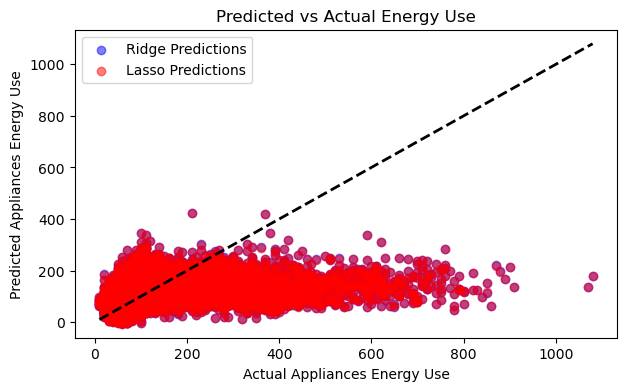

In [26]:
# 5.1) Predicted vs Actual plot

plt.figure(figsize=(7,4))
plt.scatter(y, ridge_pred, color='blue', alpha=0.5, label='Ridge Predictions')
plt.scatter(y, lasso_pred, color='red', alpha=0.5, label='Lasso Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)  # perfect fit line
plt.xlabel('Actual Appliances Energy Use')
plt.ylabel('Predicted Appliances Energy Use')
plt.title('Predicted vs Actual Energy Use')
plt.legend()
plt.show()

In [27]:
# 5.2) Ridge coefficient path

alphas_path = np.logspace(-3, 3, 100)
coefs_ridge = []

for a in alphas_path:
    ridge = Ridge(alpha=a)
    ridge.fit(x_scaled, y)
    coefs_ridge.append(ridge.coef_)

coefs_ridge = np.array(coefs_ridge)

plt.figure(figsize=(7,4))
for i in range(coefs_ridge.shape[1]):
    plt.plot(alphas_path, coefs_ridge[:, i], label=f'Feature {i}')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.title('Ridge Coefficient Path')
plt.axhline(0, color='grey', linestyle='--')
plt.show()


NameError: name 'Ridge' is not defined

In [ ]:
# 5.3) Lasso coefficient path

coefs_lasso = []

for a in alphas_path:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(x_scaled, y)
    coefs_lasso.append(lasso.coef_)

coefs_lasso = np.array(coefs_lasso)

plt.figure(figsize=(7,4))
for i in range(coefs_lasso.shape[1]):
    plt.plot(alphas_path, coefs_lasso[:, i], label=f'Feature {i}')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficient Path')
plt.axhline(0, color='grey', linestyle='--')
plt.show()


In [ ]:
# 5.4) Ridge regression coefficient (with CV) 

coef_df = pd.DataFrame({
    'feature': feature_names,
    'Ridge': ridge_coefs,
    'Lasso': lasso_coefs
}).sort_values(by='Ridge', key=abs, ascending=False)

plt.figure(figsize=(7,4))

# Plot line connecting coefficients
plt.plot(coef_df['feature'], coef_df['Ridge'], color='blue', linestyle='-', marker='o', linewidth=2, markersize=6)

plt.xticks(rotation=90)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel("Features")
plt.ylabel("Ridge Coefficient")
plt.title("Ridge Regression Coefficients (with CV)")
plt.tight_layout()
plt.show()


In [ ]:
# 5.5) Lasso regression coefficient (with CV)

plt.figure(figsize=(7,4))

# Plot line connecting coefficients
plt.plot(coef_df['feature'], coef_df['Lasso'], color='red', linestyle='-', marker='o', linewidth=2, markersize=6)

plt.xticks(rotation=90)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel("Features")
plt.ylabel("Lasso Coefficient")
plt.title("Lasso Regression Coefficients (with CV)")
plt.tight_layout()
plt.show()


In [ ]:
# 5.6) Ridge vs Lasso regression coefficients (with CV)

plt.figure(figsize=(10,6))
indices = range(len(coef_df))

# Ridge line + dots
plt.plot(indices, coef_df['Ridge'], color='blue', marker='o', linestyle='-', linewidth=2, markersize=6, label='Ridge')

# Lasso line + dots
plt.plot(indices, coef_df['Lasso'], color='red', marker='s', linestyle='-', linewidth=2, markersize=6, label='Lasso')

# Horizontal line at 0
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

# Feature names on x-axis
plt.xticks(indices, coef_df['feature'], rotation=90)

# Labels and title
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Ridge vs Lasso Regression Coefficients (with CV)")
plt.legend()
plt.tight_layout()
plt.show()
